<a href="https://colab.research.google.com/github/expaetra/CM3070_final_project/blob/master/04_baseline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

In [2]:
!git clone https://github.com/expaetra/CM3070_final_project.git
%cd CM3070_final_project

Cloning into 'CM3070_final_project'...
remote: Enumerating objects: 86, done.
remote: Counting objects: 100% (86/86), done.
remote: Compressing objects: 100% (75/75), done.
remote: Total 86 (delta 12), reused 73 (delta 5), pack-reused 0 (from 0)
Receiving objects: 100% (86/86), 15.77 MiB | 15.04 MiB/s, done.
Resolving deltas: 100% (12/12), done.
/content/CM3070-Computer-Science-Final-Project/CM3070_final_project


This baseline experiment uses TF-IDF vectorization and Logistic Regression to classify arXiv abstracts into discipline and field categories.
TF-IDF converts each abstract into a weighted numerical representation based on the importance of words and phrases within the corpus, Logistic Regression will serve as a strong and interpretable linear classifier for high dimensional text data.
The purpose of this iteration is to establish a benchmark against which more advanced classifiers and richer text representations will later be compared.

In [3]:
!git clone https://github.com/expaetra/CM3070_final_project.git
%cd CM3070_final_project

Cloning into 'CM3070_final_project'...
remote: Enumerating objects: 86, done.
remote: Counting objects: 100% (86/86), done.
remote: Compressing objects: 100% (75/75), done.
remote: Total 86 (delta 12), reused 73 (delta 5), pack-reused 0 (from 0)
Receiving objects: 100% (86/86), 15.77 MiB | 8.70 MiB/s, done.
Resolving deltas: 100% (12/12), done.
Updating files: 100% (45/45), done.
/content/CM3070-Computer-Science-Final-Project/CM3070_final_project/CM3070_final_project


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_recall_fscore_support
)
from sklearn.metrics import classification_report

In [8]:
# load the dataset

df = pd.read_csv("backend/data/arxiv_abstracts_cleaned.csv")
print(df.shape)
print(df.head())

(15717, 5)
  category             field               discipline  \
0    cs.LG  Machine Learning  Artificial Intelligence   
1    cs.LG  Machine Learning  Artificial Intelligence   
2    cs.LG  Machine Learning  Artificial Intelligence   
3    cs.LG  Machine Learning  Artificial Intelligence   
4    cs.LG  Machine Learning  Artificial Intelligence   

                                            abstract  abstract_length  
0  design rule checking (drc) is getting increasi...              117  
1  anomaly detection is a key application of mach...              125  
2  the increased reliance on the internet and the...              220  
3  clinical coding is an administrative process t...              159  
4  the translation of medical diagnosis to clinic...              154  


In [10]:
# define features and targets

X = df['abstract']
y_discipline = df['discipline']
y_field = df['field']

In [11]:
# train/test split

X_train, X_test, y_disc_train, y_disc_test, y_field_train, y_field_test = train_test_split(
    X,
    y_discipline,
    y_field,
    test_size = 0.2,
    random_state = 42,
    stratify=y_discipline
)

print(f"Train size: {len(X_train)}")
print(f"Test size: {len(X_test)}")

Train size: 12573
Test size: 3144


In [12]:
# TF-IDF for discipline

tfidf_disc = TfidfVectorizer(
    max_features=10000,
    stop_words='english',
    ngram_range=(1, 2)
)

X_train_disc = tfidf_disc.fit_transform(X_train)
X_test_disc = tfidf_disc.transform(X_test)

print("Discipline TF-IDF:")
print(X_train_disc.shape, X_test_disc.shape)

Discipline TF-IDF:
(12573, 10000) (3144, 10000)


In [13]:
# train logistic regresion for discipline

disc_model = LogisticRegression(max_iter=1000, random_state=42)
disc_model.fit(X_train_disc, y_disc_train)

print("Discipline classifier trained")

Discipline classifier trained


In [14]:
# evaluate discipline

y_disc_pred = disc_model.predict(X_test_disc)

print("Discipline: ")
print(classification_report(y_disc_test, y_disc_pred))

Discipline: 
                              precision    recall  f1-score   support

     Artificial Intelligence       0.47      0.77      0.59       689
               Communication       0.70      0.54      0.61        97
       Computational Science       0.70      0.38      0.49       100
           Computer Graphics       0.78      0.47      0.59        97
           Computer Hardware       0.65      0.59      0.62        98
 Computer Imaging and Vision       0.45      0.24      0.31       100
           Computer Networks       0.54      0.51      0.52        98
        Computer Programming       0.59      0.44      0.51        97
            Computer Systems       0.51      0.42      0.46       198
               Cybersecurity       0.47      0.41      0.44        99
         Distributed Systems       0.28      0.15      0.20       100
       Emerging Technologies       0.68      0.67      0.67        99
  Human-Computer Interaction       0.46      0.26      0.33        99
      

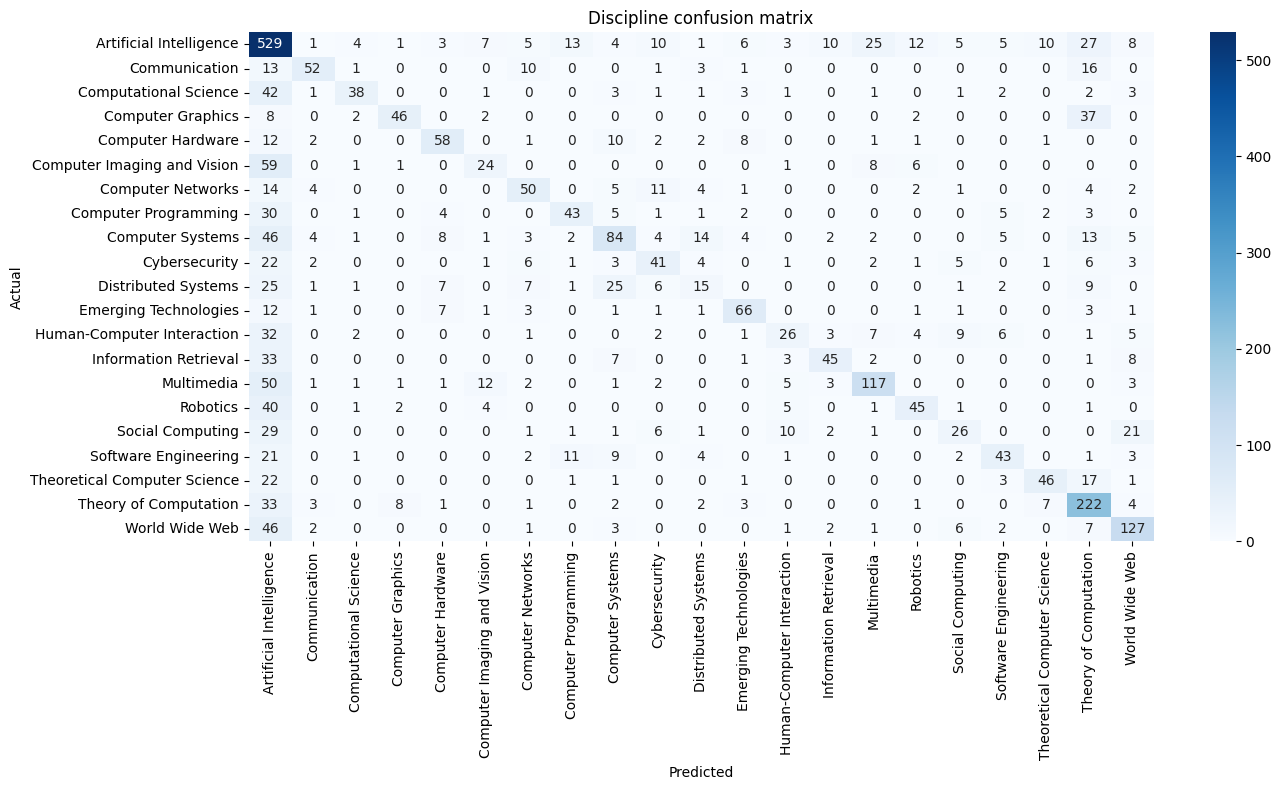

In [15]:
# confusion matrix for discipline

disc_labels = sorted(y_disc_test.unique())
disc_cm = confusion_matrix(y_disc_test, y_disc_pred,labels=disc_labels)

plt.figure(figsize=(14, 8))
sns.heatmap(disc_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=disc_labels, yticklabels=disc_labels)
plt.title("Discipline confusion matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [20]:
# print the table

report_disc = classification_report(y_disc_test, y_disc_pred, output_dict=True)

report_df = pd.DataFrame(report_disc).transpose()
print(report_df)
report_df.round(3)

                              precision    recall  f1-score      support
Artificial Intelligence        0.473166  0.767779  0.585501   689.000000
Communication                  0.702703  0.536082  0.608187    97.000000
Computational Science          0.703704  0.380000  0.493506   100.000000
Computer Graphics              0.779661  0.474227  0.589744    97.000000
Computer Hardware              0.651685  0.591837  0.620321    98.000000
Computer Imaging and Vision    0.452830  0.240000  0.313725   100.000000
Computer Networks              0.537634  0.510204  0.523560    98.000000
Computer Programming           0.589041  0.443299  0.505882    97.000000
Computer Systems               0.512195  0.424242  0.464088   198.000000
Cybersecurity                  0.465909  0.414141  0.438503    99.000000
Distributed Systems            0.283019  0.150000  0.196078   100.000000
Emerging Technologies          0.680412  0.666667  0.673469    99.000000
Human-Computer Interaction     0.456140  0.262626  

,precision,recall,f1-score,support
Artificial Intelligence,0.473,0.768,0.586,689.000
Communication,0.703,0.536,0.608,97.000
Computational Science,0.704,0.380,0.494,100.000
Computer Graphics,0.780,0.474,0.590,97.000
Computer Hardware,0.652,0.592,0.620,98.000
Computer Imaging and Vision,0.453,0.240,0.314,100.000
Computer Networks,0.538,0.510,0.524,98.000
Computer Programming,0.589,0.443,0.506,97.000
Computer Systems,0.512,0.424,0.464,198.000
Cybersecurity,0.466,0.414,0.439,99.000


In [21]:
# TF-IDF for field

tfidf_field = TfidfVectorizer(
    max_features=10000,
    stop_words='english',
    ngram_range=(1, 2)
)

X_train_field = tfidf_field.fit_transform(X_train)
X_test_field = tfidf_field.transform(X_test)

print("Field TF-IDF:")
print(X_train_field.shape, X_test_field.shape)

Field TF-IDF:
(12573, 10000) (3144, 10000)


In [22]:
# train logistic regression for field

field_model = LogisticRegression(max_iter=1000,random_state=42)
field_model.fit(X_train_field, y_field_train)

print("Field classifier trained")

Field classifier trained


In [24]:
# evaluate field

y_field_pred = field_model.predict(X_test_field)
print("Field: ")
print(classification_report(y_field_test, y_field_pred))

Field: 
                                      precision    recall  f1-score   support

            Computational Complexity       0.52      0.45      0.48       106
           Computational Engineering       0.54      0.57      0.56       100
              Computational Geometry       0.67      0.68      0.67        97
                     Computer Vision       0.44      0.55      0.49       100
               Computers and Society       0.41      0.37      0.39        99
                        Cryptography       0.44      0.51      0.47        99
      Data Structures and Algorithms       0.27      0.43      0.33        81
                    Database Systems       0.55      0.51      0.53       101
                   Digital Libraries       0.67      0.74      0.70        95
                Discrete Mathematics       0.47      0.44      0.45       100
        Distributed Computer Systems       0.25      0.20      0.22       100
               Emerging Technologies       0.65      0.

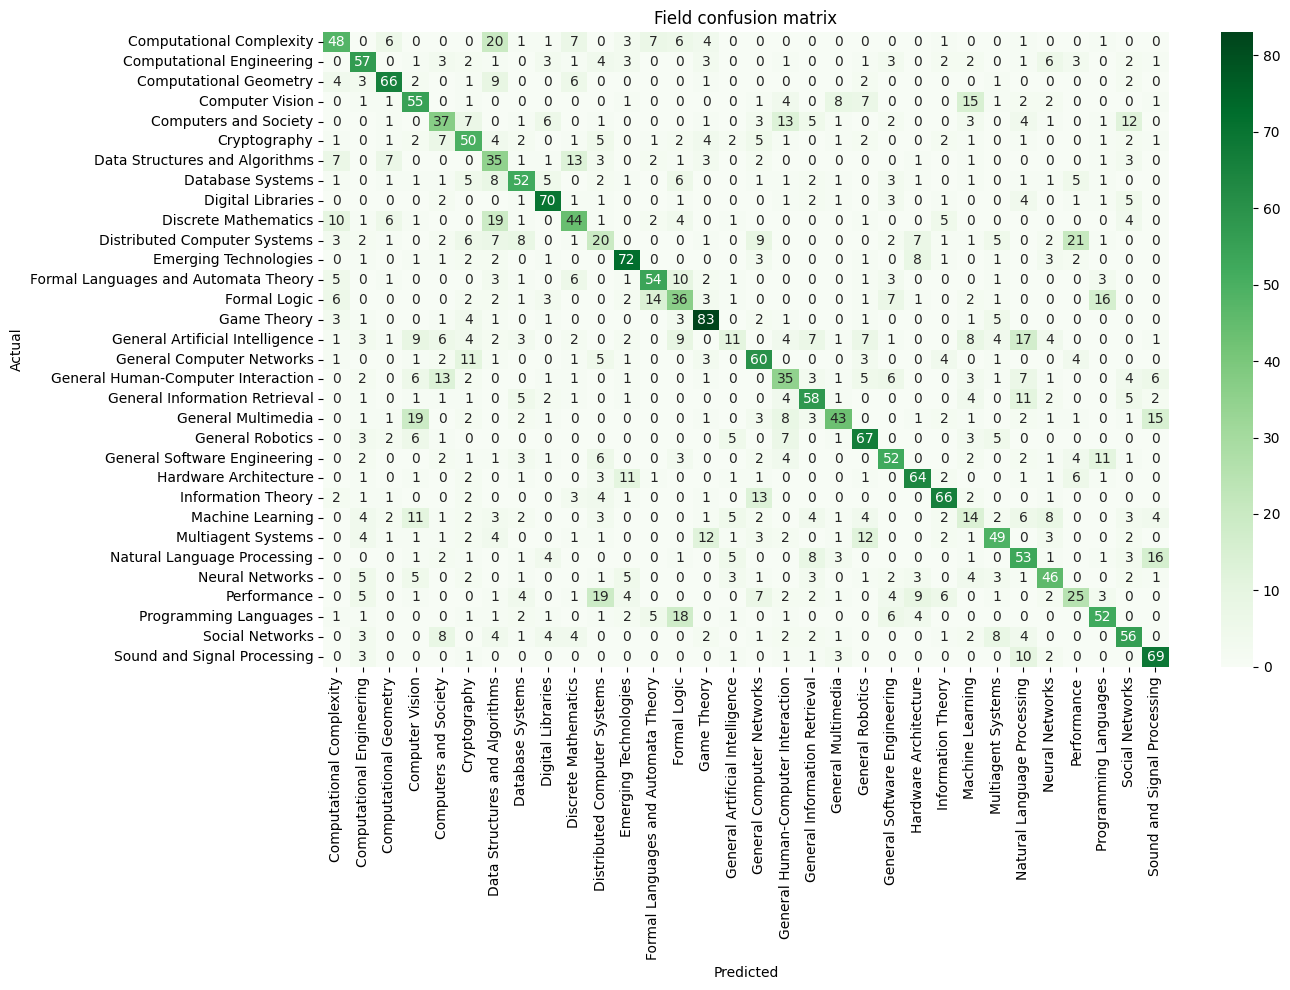

In [27]:
# confusion matrix for field

field_labels = sorted(y_field_test.unique())
field_cm = confusion_matrix(y_field_test, y_field_pred, labels=field_labels)

plt.figure(figsize=(14, 10))
sns.heatmap(field_cm, annot=True, fmt='d',cmap='Greens',
            xticklabels=field_labels, yticklabels=field_labels)
plt.title("Field confusion matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [28]:
# print the table

report_field = classification_report(y_field_test, y_field_pred, output_dict=True)

report_df = pd.DataFrame(report_field).transpose()
print(report_df)
report_df.round(3)

                                      precision    recall  f1-score  \
Computational Complexity               0.516129  0.452830  0.482412   
Computational Engineering              0.542857  0.570000  0.556098   
Computational Geometry                 0.666667  0.680412  0.673469   
Computer Vision                        0.440000  0.550000  0.488889   
Computers and Society                  0.406593  0.373737  0.389474   
Cryptography                           0.438596  0.505051  0.469484   
Data Structures and Algorithms         0.273438  0.432099  0.334928   
Database Systems                       0.553191  0.514851  0.533333   
Digital Libraries                      0.666667  0.736842  0.700000   
Discrete Mathematics                   0.468085  0.440000  0.453608   
Distributed Computer Systems           0.250000  0.200000  0.222222   
Emerging Technologies                  0.648649  0.727273  0.685714   
Formal Languages and Automata Theory   0.627907  0.586957  0.606742   
Formal

,precision,recall,f1-score,support
Computational Complexity,0.516,0.453,0.482,106.000
Computational Engineering,0.543,0.570,0.556,100.000
Computational Geometry,0.667,0.680,0.673,97.000
Computer Vision,0.440,0.550,0.489,100.000
Computers and Society,0.407,0.374,0.389,99.000
Cryptography,0.439,0.505,0.469,99.000
Data Structures and Algorithms,0.273,0.432,0.335,81.000
Database Systems,0.553,0.515,0.533,101.000
Digital Libraries,0.667,0.737,0.700,95.000
Discrete Mathematics,0.468,0.440,0.454,100.000


In [30]:
# results table

def get_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true, y_pred, average='macro', zero_division=0
    )
    precision_weighted,recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        y_true, y_pred, average='weighted', zero_division=0
    )

    return {
        'Accuracy': acc,
        'Macro Precision': precision_macro,
        'Macro Recall': recall_macro,
        'Macro F1': f1_macro,
        'Weighted Precision': precision_weighted,
        'Weighted Recall': recall_weighted,
        'Weighted F1': f1_weighted
    }

d_results = get_metrics(y_disc_test, y_disc_pred)
f_results = get_metrics(y_field_test, y_field_pred)

summary_df = pd.DataFrame([
    {'Task': 'Discipline', 'Model': 'TF-IDF + Logistic regression', **d_results},
    {'Task': 'Field', 'Model': 'TF-IDF + Logistic regression', **f_results}
])

summary_df = summary_df.round(3)
summary_df

,Task,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted Precision,Weighted Recall,Weighted F1
0,Discipline,TF-IDF + Logistic regression,0.554,0.583,0.475,0.513,0.566,0.554,0.543
1,Field,TF-IDF + Logistic regression,0.509,0.501,0.509,0.500,0.503,0.509,0.501


The baseling which uses TF-IDF features and logistic regression show mmoderate performance for field and discipline categories.

The discipline classification achieves an accuracy of 0.554, macro F1-score of 0.513, whihc indicates that even though the model performs reasonably well overall, performance varies across classes. The lower macro recall (0.475) implies that some disciplines are more difficult to identify, which is likely due to overlapping vocabulary.

For the field classification, the model achieves slightly lower performance, its accuracy is 0.509 and a macro F1-score 0.500. This is a more balanced but overall weaker classification.
The results are consistent with earlier analysis which showed vocabulary overlap between certain disciplines, which is why they are harder to distinguish.

In [34]:
# save the results

import os

os.makedirs("/content/drive/MyDrive/CM3070_final_project/backend/data", exist_ok=True)
summary_df.to_csv(
    "/content/drive/MyDrive/CM3070_final_project/backend/data/iteration1_baseline_results.csv",
    index=False
)

print(f"Saved.")

Saved.
